# Participant 3: held-out predictive comparison with the Switching observer

This notebook compares the three standardized hierarchical observers against a
standardized version of the original Switching observer. Parameters are fitted
only to earlier-session responses. The final two complete sessions are then
scored trial by trial with log predictive probability.

The split is chronological and session based. Every model retains the full
direction-feedback sequence, but training responses are masked from the
likelihood outside the training sessions. A held-out session starts from the
same reset state used during fitting. Stateful observers may update from
feedback revealed after earlier held-out trials, but no held-out response and no
future trial enters a prediction.

## Standardized Switching observer

The supplied `Switching_Bayesian_Observer_starter2.ipynb` defines the original
Switching response distribution in its Figure 6 implementation. For coherence
(c), its prior-switch probability is

\[
w_c = \frac{\kappa_p}{\kappa_p + \kappa_{e,c}}.
\]

Before response noise, the participant either reports the prior mean or a
sensory draw:

\[
p(q_t\mid d_t,c_t)=w_{c_t}\,\delta(q_t-\mu_0)
 +(1-w_{c_t})VM(q_t;d_t,\kappa_{e,c_t}).
\]

The common observation model then convolves this distribution with the fitted
motor von Mises kernel and mixes in the same uniform lapse probability used by
all four models.

The source notebook used a 1-degree grid and four concentrations indexed by the
experimenter's `prior_std`. For a fair comparison here, every model uses the
shared 5-degree grid and the Switching observer has one fitted participant-level
(\kappa_p). The model never receives `prior_std`.

## Four models under one contract

| Model | Prior-use mechanism | Participant parameters |
|---|---|---|
| `switching_observer` | Fixed reliability-ratio switch, point prior branch | 3 sensory kappas, prior kappa, motor kappa, lapse |
| `readout_average` | Learns a distribution over prior kappa and averages conditional MAP readouts | 3 sensory kappas, alpha, forgetting, motor kappa, lapse |
| `reliability_mixture` | Learns trial-level prior reliance from recent feedback | 3 sensory kappas, prior kappa, learning rate, motor kappa, lapse |
| `integrated_prior` | Learns uncertainty over prior kappa, integrates the prior, then takes one MAP readout | rho, 3 sensory kappas, motor kappa, lapse |

All models share trial order, feedback, session resets, response bins, motor
noise, lapse process, bounded two-start Powell fitting, and held-out trials.

In [1]:
from __future__ import annotations

import json
import os
import sys
from itertools import combinations
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    candidates = [start.resolve(), *start.resolve().parents]
    for candidate in candidates:
        if (candidate / "src" / "standardized_hb").exists():
            return candidate
        nested = candidate / "standardized_hierarchical_comparison"
        if (nested / "src" / "standardized_hb").exists():
            return nested
    raise FileNotFoundError("Could not locate standardized_hierarchical_comparison.")


PROJECT_ROOT = find_project_root(Path.cwd())
WORKSPACE_ROOT = PROJECT_ROOT.parent
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from standardized_hb import (
    FitConfig,
    GridSpec,
    IntegratedPriorObserver,
    ReadoutAverageObserver,
    ReliabilityMixtureObserver,
    SwitchingObserver,
    fit_model,
    last_sessions_holdout,
    load_participant,
    observed_log_scores,
    paired_block_bootstrap_difference,
    predictive_score_record,
    with_response_mask,
)
from standardized_hb.circular import angle_to_bin, wrap_signed_degrees
from standardized_hb.plotting import MODEL_COLORS

print("project:", PROJECT_ROOT)

project: C:\Users\HP\Desktop\baysiean hyperprior\standardized_hierarchical_comparison


## Run configuration

The normal run uses two starts and 250 objective evaluations per start. The
integrated-prior model dominates runtime and can take approximately 45-90
minutes on this machine. Set `HB_MAX_EVALUATIONS_PER_START` to a larger value
if the convergence table still reports an evaluation-limit exit.

Set `HB_SMOKE_TEST=1` for a five-evaluation pipeline check. Smoke scores are not
scientific results.

In [2]:
SMOKE_TEST = os.environ.get("HB_SMOKE_TEST", "0") == "1"
PARTICIPANT_ID = int(os.environ.get("HB_PARTICIPANT_ID", "3"))
HOLDOUT_SESSION_COUNT = int(os.environ.get("HB_HOLDOUT_SESSIONS", "2"))
NORMAL_MAX_EVALUATIONS_PER_START = int(
    os.environ.get("HB_MAX_EVALUATIONS_PER_START", "250")
)
BOOTSTRAP_DRAWS = int(os.environ.get("HB_BOOTSTRAP_DRAWS", "5000"))
if not SMOKE_TEST and NORMAL_MAX_EVALUATIONS_PER_START < 100:
    raise ValueError("Normal fits require at least 100 evaluations per start.")

GRID = GridSpec(
    n_angles=72,
    n_positive_kappa=9,
    kappa_min=0.05,
    kappa_max=50.0,
    prior_mean_degrees=225.0,
)
FIT_CONFIG = FitConfig(
    n_starts=1 if SMOKE_TEST else 2,
    max_evaluations_per_start=5 if SMOKE_TEST else NORMAL_MAX_EVALUATIONS_PER_START,
    seed=20260721,
)
RUN_LABEL = (
    f"smoke_participant_{PARTICIPANT_ID}_predictive"
    if SMOKE_TEST
    else f"participant_{PARTICIPANT_ID}_predictive"
)
OUTPUT_DIR = PROJECT_ROOT / "outputs" / RUN_LABEL
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

run_config = {
    "smoke_test": SMOKE_TEST,
    "participant_id": PARTICIPANT_ID,
    "heldout_final_sessions": HOLDOUT_SESSION_COUNT,
    "n_angles": GRID.n_angles,
    "angle_step_degrees": 360.0 / GRID.n_angles,
    "n_starts": FIT_CONFIG.n_starts,
    "max_evaluations_per_start": FIT_CONFIG.max_evaluations_per_start,
    "bootstrap_draws": BOOTSTRAP_DRAWS,
    "prior_std_used": False,
    "split": "complete final sessions",
    "heldout_state_policy": "reset at session start; causal feedback updates only",
}
display(pd.DataFrame.from_dict(run_config, orient="index", columns=["value"]))

,value
smoke_test,False
participant_id,3
heldout_final_sessions,2
n_angles,72
angle_step_degrees,5.0
n_starts,2
max_evaluations_per_start,250
bootstrap_draws,5000
prior_std_used,False
split,complete final sessions


## Load participant and create the chronological split

The final sessions are held out as complete units. This tests whether fitted
participant parameters generalize to new sessions while preserving each
model's causal within-session update rule.

In [3]:
DATA_CANDIDATES = [
    WORKSPACE_ROOT / "hierarchical" / "data" / "data01_direction4priors.csv",
    Path.home() / "Downloads" / "data01_direction4priors.csv",
]
DATA_CSV = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_CSV is None:
    raise FileNotFoundError(f"Data not found. Checked: {DATA_CANDIDATES}")

subject, audit = load_participant(DATA_CSV, subject_id=PARTICIPANT_ID, grid=GRID)
assert not hasattr(subject, "prior_std")
assert audit["prior_std_used"] is False

split = last_sessions_holdout(subject, n_sessions=HOLDOUT_SESSION_COUNT)
training_subject = with_response_mask(subject, split.train_mask)
assert training_subject.n_trials == subject.n_trials
assert not np.any(training_subject.response_valid & split.test_mask)

session_rows = []
for session_id in subject.session_ids[np.flatnonzero(subject.reset_before)]:
    selector = subject.session_ids == session_id
    session_rows.append(
        {
            "session": session_id,
            "split": "held_out" if session_id in split.heldout_sessions else "train",
            "trials": int(selector.sum()),
            "valid_responses": int(np.count_nonzero(selector & subject.response_valid)),
        }
    )
split_table = pd.DataFrame(session_rows)
display(pd.DataFrame.from_dict(audit, orient="index", columns=["value"]))
display(split_table)
print(
    "train valid responses:", training_subject.n_valid_responses,
    "| held-out valid responses:", int(np.count_nonzero(split.test_mask & subject.response_valid)),
    "| held-out sessions:", split.heldout_sessions,
)

,value
csv_path,C:\Users\HP\Desktop\baysiean hyperprior\hierar...
subject_id,3
trials,9412
valid_responses,9412
sessions,9
runs,44
coherences,"[0.06, 0.12, 0.24]"
prior_mean_degrees,225.0
prior_std_used,False


,session,split,trials,valid_responses
0,1,train,1065,1065
1,2,train,1065,1065
2,3,train,1065,1065
3,4,train,1065,1065
4,5,train,1065,1065
5,6,train,850,850
6,7,train,1079,1079
7,8,held_out,1079,1079
8,9,held_out,1079,1079


train valid responses: 7254 | held-out valid responses: 2158 | held-out sessions: (8, 9)


## Construct all four observers and validate default predictions

In [4]:
observers = {
    "switching_observer": SwitchingObserver(training_subject, GRID, batch_size=128),
    "readout_average": ReadoutAverageObserver(training_subject, GRID, batch_size=128),
    "reliability_mixture": ReliabilityMixtureObserver(training_subject, GRID, batch_size=128),
    "integrated_prior": IntegratedPriorObserver(training_subject, GRID, batch_size=128),
}

preflight = []
for name, observer in observers.items():
    started = perf_counter()
    raw = observer.default_raw_parameters()
    prediction = observer.predict(raw)
    row_sums = prediction.response_pmfs.sum(axis=1)
    preflight.append(
        {
            "model": name,
            "parameters": observer.parameter_count,
            "default_train_nll": observer.negative_log_likelihood(raw),
            "maximum_normalization_error": float(np.max(np.abs(row_sums - 1.0))),
            "elapsed_seconds": perf_counter() - started,
        }
    )
preflight_table = pd.DataFrame(preflight)
assert (preflight_table["maximum_normalization_error"] < 1e-10).all()
display(preflight_table)

,model,parameters,default_train_nll,maximum_normalization_error,elapsed_seconds
0,switching_observer,6,21985.526162,2.220446e-16,0.172251
1,readout_average,7,21236.523393,4.440892e-16,0.416442
2,reliability_mixture,7,24375.276900,3.330669e-16,0.628479
3,integrated_prior,6,21617.949997,4.440892e-16,9.662634


## Fit training responses

The full chronological direction sequence is retained so state trajectories are
causal and aligned, but only training-session responses contribute to the
objective. Held-out responses cannot affect parameter estimation.

In [5]:
fit_results = {}
for name, observer in observers.items():
    print(f"Fitting {name} ...", flush=True)
    result = fit_model(observer, FIT_CONFIG)
    fit_results[name] = result
    print(
        f"  train NLL={result.nll:.2f}, evaluations={result.evaluations}, "
        f"elapsed={result.elapsed_seconds:.1f}s, success={result.success}",
        flush=True,
    )

Fitting switching_observer ...
  train NLL=20923.65, evaluations=350, elapsed=30.7s, success=True
Fitting readout_average ...
  train NLL=20626.15, evaluations=449, elapsed=97.8s, success=True
Fitting reliability_mixture ...
  train NLL=20882.26, evaluations=500, elapsed=151.9s, success=False
Fitting integrated_prior ...
  train NLL=20738.89, evaluations=415, elapsed=2293.6s, success=True


## Training fit and convergence diagnostics

In [6]:
comparison_valid = all(result.success for result in fit_results.values())
train_score_table = pd.DataFrame(
    [
        {
            "model": name,
            "n_parameters": observers[name].parameter_count,
            "train_nll": result.nll,
            "train_aic": result.aic,
            "train_bic": result.bic,
            "evaluations": result.evaluations,
            "elapsed_seconds": result.elapsed_seconds,
            "optimizer_success": result.success,
            "comparison_valid": comparison_valid,
        }
        for name, result in fit_results.items()
    ]
).sort_values("train_aic").reset_index(drop=True)
display(train_score_table)

parameter_table = pd.DataFrame(
    {name: result.parameters for name, result in fit_results.items()}
).T
display(parameter_table)

convergence_rows = []
for name, result in fit_results.items():
    observer = observers[name]
    fitted = np.asarray(result.raw_parameters)
    initial = observer.default_raw_parameters()
    bounds = np.asarray(observer.raw_bounds, dtype=float)
    tolerance = 1e-3 * (bounds[:, 1] - bounds[:, 0])
    unchanged = np.abs(fitted - initial) <= tolerance
    at_bound = (
        (fitted - bounds[:, 0] <= tolerance)
        | (bounds[:, 1] - fitted <= tolerance)
    )
    convergence_rows.append(
        {
            "model": name,
            "success": result.success,
            "message": result.message,
            "unchanged_raw_parameters": ", ".join(
                np.asarray(observer.raw_parameter_names)[unchanged]
            ) or "none",
            "bound_hits": ", ".join(
                np.asarray(observer.raw_parameter_names)[at_bound]
            ) or "none",
        }
    )
convergence_table = pd.DataFrame(convergence_rows)
display(convergence_table)
if not comparison_valid:
    print(
        "WARNING: At least one fit did not converge. Held-out scores are useful "
        "pipeline diagnostics but the model comparison remains provisional."
    )

,model,n_parameters,train_nll,train_aic,train_bic,evaluations,elapsed_seconds,optimizer_success,comparison_valid
0,readout_average,7,20626.154315,41266.308629,41314.533787,449,97.789242,True,False
1,integrated_prior,6,20738.889228,41489.778455,41531.114305,415,2293.639120,True,False
2,reliability_mixture,7,20882.258625,41778.517249,41826.742408,500,151.920750,False,False
3,switching_observer,6,20923.651806,41859.303613,41900.639462,350,30.681130,True,False


,prior_kappa,motor_kappa,lapse,sensory_kappa_0.06,sensory_kappa_0.12,sensory_kappa_0.24,alpha,lambda,learning_rate,rho
switching_observer,3.247676,38.958680,0.026375,4.037289,16.457138,79.953453,NaN,NaN,NaN,NaN
readout_average,NaN,33.442284,0.013566,2.577151,10.225270,79.955849,0.655326,0.237896,NaN,NaN
reliability_mixture,79.388473,41.019137,0.014610,2.887299,16.441709,79.999775,NaN,NaN,0.068174,NaN
integrated_prior,NaN,26.198032,0.019839,2.613119,9.921376,79.811024,NaN,NaN,NaN,0.712822


,model,success,message,unchanged_raw_parameters,bound_hits
0,switching_observer,True,Optimization terminated successfully.,none,log_sensory_kappa_0.24
1,readout_average,True,Optimization terminated successfully.,none,log_sensory_kappa_0.24
2,reliability_mixture,False,Maximum number of function evaluations has bee...,none,log_sensory_kappa_0.24
3,integrated_prior,True,Optimization terminated successfully.,none,log_sensory_kappa_0.24


## Held-out predictive log likelihood

For each held-out response (r_t), the score is

\[
\log p(r_t\mid d_{1:t}, c_{1:t}, \hat\theta_{train}).
\]

`heldout_elpd` is the sum of these log probabilities; larger values are better.
`bits_per_trial_over_uniform` reports the average improvement over a uniform
72-bin response model. Unlike training AIC, this comparison directly evaluates
out-of-sample prediction.

In [7]:
predictions = {
    name: observers[name].predict(result.raw_parameters)
    for name, result in fit_results.items()
}
heldout_indices = np.flatnonzero(split.test_mask & subject.response_valid)
heldout_blocks = np.column_stack(
    (subject.session_ids[heldout_indices], subject.run_ids[heldout_indices])
)
heldout_log_scores = {
    name: observed_log_scores(subject, prediction, split.test_mask)
    for name, prediction in predictions.items()
}
if len({scores.size for scores in heldout_log_scores.values()}) != 1:
    raise RuntimeError("Models were not scored on identical held-out responses.")

predictive_table = pd.DataFrame(
    [
        predictive_score_record(name, scores, GRID.n_angles)
        for name, scores in heldout_log_scores.items()
    ]
).sort_values("heldout_elpd", ascending=False).reset_index(drop=True)
predictive_table["heldout_nll"] = -predictive_table["heldout_elpd"]
predictive_table["elpd_difference_from_best"] = (
    predictive_table["heldout_elpd"] - predictive_table["heldout_elpd"].max()
)
predictive_table["comparison_valid"] = comparison_valid
display(predictive_table)

,model,heldout_trials,heldout_elpd,mean_log_score,bits_per_trial_over_uniform,heldout_nll,elpd_difference_from_best,comparison_valid
0,readout_average,2158,-6310.136478,-2.924067,1.951388,6310.136478,0.000000,False
1,integrated_prior,2158,-6348.516415,-2.941852,1.925730,6348.516415,-38.379937,False
2,reliability_mixture,2158,-6379.213559,-2.956077,1.905208,6379.213559,-69.077082,False
3,switching_observer,2158,-6399.291865,-2.965381,1.891785,6399.291865,-89.155387,False


## Paired run-block uncertainty

All models score the same held-out trials, so uncertainty is computed from
paired log-score differences. Complete `(session, run)` blocks are resampled to
preserve local trial dependence. A 95% interval entirely above zero supports
the first model in a pair; an interval entirely below zero supports the second.

In [8]:
pairwise_rows = []
for first, second in combinations(heldout_log_scores, 2):
    comparison = paired_block_bootstrap_difference(
        heldout_log_scores[first],
        heldout_log_scores[second],
        heldout_blocks,
        n_draws=BOOTSTRAP_DRAWS,
        seed=FIT_CONFIG.seed,
    )
    lower = comparison["ci_2.5%"]
    upper = comparison["ci_97.5%"]
    if lower > 0.0:
        supported_model = first
    elif upper < 0.0:
        supported_model = second
    else:
        supported_model = "inconclusive"
    pairwise_rows.append(
        {
            "first_model": first,
            "second_model": second,
            "mean_log_score_difference_first_minus_second": comparison["mean_difference"],
            "ci_2.5%": lower,
            "ci_97.5%": upper,
            "probability_first_better": comparison["probability_first_better"],
            "run_blocks": comparison["blocks"],
            "supported_model_if_converged": supported_model,
            "comparison_valid": comparison_valid,
        }
    )
pairwise_table = pd.DataFrame(pairwise_rows)
display(pairwise_table)

,first_model,second_model,mean_log_score_difference_first_minus_second,ci_2.5%,ci_97.5%,probability_first_better,run_blocks,supported_model_if_converged,comparison_valid
0,switching_observer,readout_average,-0.041314,-0.087493,0.009307,0.0544,10,inconclusive,False
1,switching_observer,reliability_mixture,-0.009304,-0.044142,0.026796,0.2992,10,inconclusive,False
2,switching_observer,integrated_prior,-0.023529,-0.080213,0.035907,0.2126,10,inconclusive,False
3,readout_average,reliability_mixture,0.032010,0.003596,0.055055,0.9860,10,readout_average,False
4,readout_average,integrated_prior,0.017785,0.003823,0.031811,0.9940,10,readout_average,False
5,reliability_mixture,integrated_prior,-0.014225,-0.041604,0.019382,0.1770,10,inconclusive,False


## Predictive comparison figures

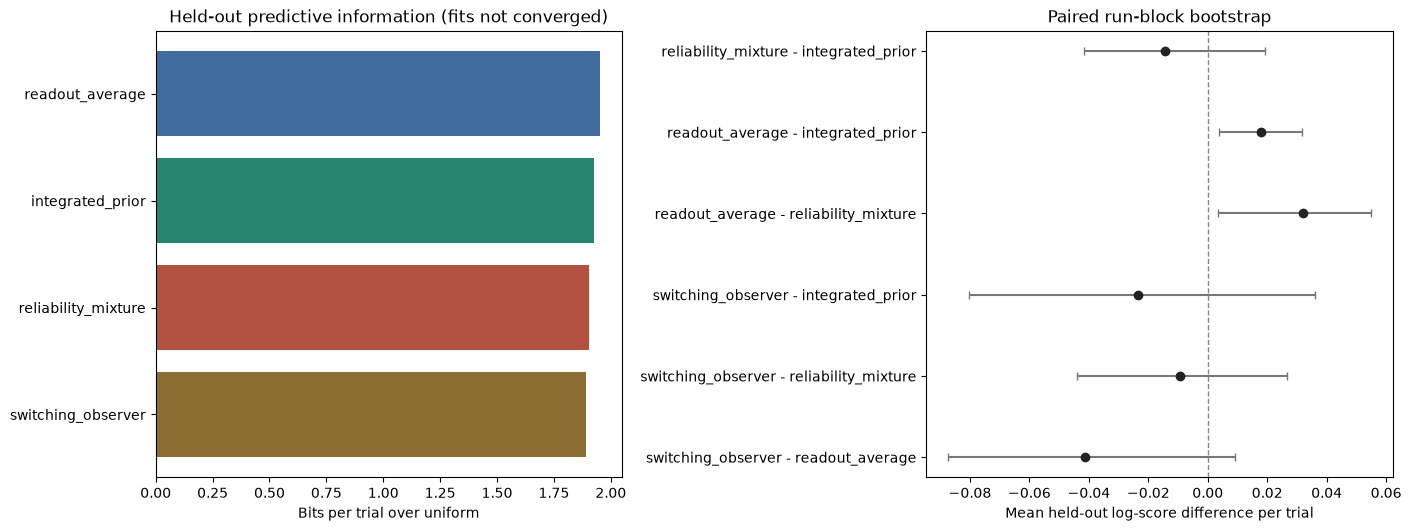

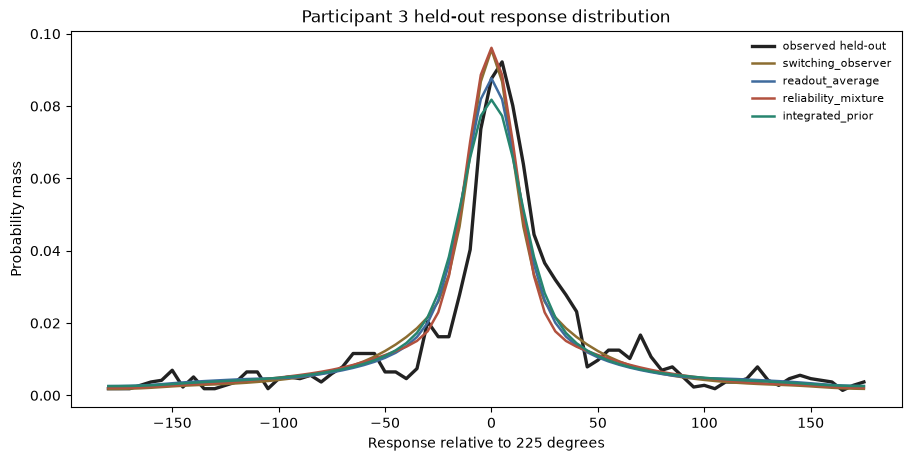

In [9]:
ordered = predictive_table.sort_values("bits_per_trial_over_uniform")
figure, axes = plt.subplots(1, 2, figsize=(14, 5.2), constrained_layout=True)
axes[0].barh(
    ordered["model"],
    ordered["bits_per_trial_over_uniform"],
    color=[MODEL_COLORS[name] for name in ordered["model"]],
)
axes[0].set(
    title=(
        "Held-out predictive information"
        if comparison_valid
        else "Held-out predictive information (fits not converged)"
    ),
    xlabel="Bits per trial over uniform",
)

y = np.arange(len(pairwise_table))
means = pairwise_table["mean_log_score_difference_first_minus_second"].to_numpy()
lower_error = means - pairwise_table["ci_2.5%"].to_numpy()
upper_error = pairwise_table["ci_97.5%"].to_numpy() - means
axes[1].errorbar(
    means,
    y,
    xerr=np.vstack((lower_error, upper_error)),
    fmt="o",
    color="#222222",
    ecolor="#777777",
    capsize=3,
)
axes[1].axvline(0.0, color="#888888", linestyle="--", linewidth=1.0)
axes[1].set_yticks(
    y,
    [
        f"{row.first_model} - {row.second_model}"
        for row in pairwise_table.itertuples()
    ],
)
axes[1].set(
    title="Paired run-block bootstrap",
    xlabel="Mean held-out log-score difference per trial",
)
figure.savefig(OUTPUT_DIR / "heldout_predictive_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

valid_test = split.test_mask & subject.response_valid
counts = np.bincount(subject.response_bins[valid_test], minlength=GRID.n_angles).astype(float)
observed_pmf = counts / counts.sum()
reference_bin = int(angle_to_bin(GRID.prior_mean_degrees, GRID.n_angles))
relative = wrap_signed_degrees(GRID.theta_degrees)
order = np.argsort(relative)

response_figure, axis = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
axis.plot(
    relative[order],
    np.roll(observed_pmf, -reference_bin)[order],
    color="#222222",
    linewidth=2.4,
    label="observed held-out",
)
for name, prediction in predictions.items():
    predicted_pmf = prediction.response_pmfs[valid_test].mean(axis=0)
    axis.plot(
        relative[order],
        np.roll(predicted_pmf, -reference_bin)[order],
        color=MODEL_COLORS[name],
        linewidth=1.8,
        label=name,
    )
axis.set(
    title=f"Participant {PARTICIPANT_ID} held-out response distribution",
    xlabel=f"Response relative to {GRID.prior_mean_degrees:g} degrees",
    ylabel="Probability mass",
)
axis.legend(frameon=False, fontsize=8)
response_figure.savefig(OUTPUT_DIR / "heldout_response_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

## Save reproducible outputs

In [10]:
payload = {
    "run_config": run_config,
    "data_audit": audit,
    "heldout_sessions": list(split.heldout_sessions),
    "comparison_valid": comparison_valid,
    "fits": {name: result.summary_record() for name, result in fit_results.items()},
    "predictive_scores": predictive_table.to_dict(orient="records"),
    "pairwise_bootstrap": pairwise_table.to_dict(orient="records"),
}
with (OUTPUT_DIR / "predictive_summary.json").open("w", encoding="utf-8") as handle:
    json.dump(
        payload,
        handle,
        indent=2,
        default=lambda value: value.item() if hasattr(value, "item") else str(value),
    )

train_score_table.to_csv(OUTPUT_DIR / "training_scores.csv", index=False)
parameter_table.to_csv(OUTPUT_DIR / "fitted_parameters.csv", index=True)
convergence_table.to_csv(OUTPUT_DIR / "convergence_diagnostics.csv", index=False)
predictive_table.to_csv(OUTPUT_DIR / "heldout_predictive_scores.csv", index=False)
pairwise_table.to_csv(OUTPUT_DIR / "pairwise_block_bootstrap.csv", index=False)
np.savez_compressed(
    OUTPUT_DIR / "heldout_trial_log_scores.npz",
    heldout_indices=heldout_indices,
    heldout_blocks=heldout_blocks,
    **heldout_log_scores,
)
for name, result in fit_results.items():
    result.history.to_csv(OUTPUT_DIR / f"{name}_optimization_history.csv", index=False)
    np.savez_compressed(
        OUTPUT_DIR / f"{name}_predictions.npz",
        response_pmfs=predictions[name].response_pmfs,
        state=predictions[name].state,
        raw_parameters=result.raw_parameters,
    )
print("saved:", OUTPUT_DIR)

saved: C:\Users\HP\Desktop\baysiean hyperprior\standardized_hierarchical_comparison\outputs\participant_3_predictive


## Interpretation gate

- Treat the predictive ranking as valid only when every optimizer reports
  success and the convergence table shows no unexplained unchanged parameters
  or boundary solutions.
- The held-out score is the primary comparison. Training AIC is retained only
  as a diagnostic and should not override worse held-out prediction.
- A pairwise interval excluding zero is participant-3 evidence for predictive
  separation on these final sessions, not a population-level conclusion.
- The block bootstrap measures uncertainty across held-out runs. It does not
  include uncertainty from parameter estimation or selection of this split.
- The Switching observer is standardized intentionally: one prior kappa and the
  shared 5-degree observation grid replace its source notebook's four
  `prior_std`-indexed kappas and 1-degree grid.
- Smoke-mode scores only verify execution.